<a href="https://colab.research.google.com/github/masroor202233/masroor202233.github.io/blob/master/Gold_edge_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import os

# Define the expected filename
DATA_FILE = 'XAUUSD_M5_5years.csv'

if os.path.exists(DATA_FILE):
    print(f"File '{DATA_FILE}' already exists in the environment. Ready to use.")
else:
    print(f"Please upload your {DATA_FILE} file:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f'User uploaded file "{filename}"')
        # If they upload a file with a different name, we update DATA_FILE
        DATA_FILE = filename

Please upload your XAUUSD_M5_5years.csv file:


Saving xau_usd_dataset_London-Strategic-Edge (1).csv to xau_usd_dataset_London-Strategic-Edge (1).csv
User uploaded file "xau_usd_dataset_London-Strategic-Edge (1).csv"


In [4]:
!pip install pandas_ta --quiet

import pandas as pd
import numpy as np
import pandas_ta as ta

# Inspect the first few lines to confirm headers
print("Checking file headers...")
print(pd.read_csv(DATA_FILE, nrows=0).columns.tolist())

# Load the data - based on your file, the column is named 'timestamp'
# We will use 'timestamp' and then rename it to 'datetime' for consistency if needed
df = pd.read_csv(DATA_FILE, parse_dates=['timestamp'])
df.rename(columns={'timestamp': 'datetime'}, inplace=True)

df.sort_values('datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

print("Data loaded successfully:", df.shape)
display(df.head())

Checking file headers...
['timestamp', 'open', 'high', 'low', 'close', 'volume']
Data loaded successfully: (448871, 6)


,datetime,open,high,low,close,volume
0,2020-01-01 23:00:00+00:00,1520.578,1520.987,1519.040,1520.799,239.0
1,2020-01-01 23:05:00+00:00,1520.758,1521.368,1520.656,1520.986,81.0
2,2020-01-01 23:10:00+00:00,1520.939,1520.939,1519.644,1519.852,117.0
3,2020-01-01 23:15:00+00:00,1519.802,1520.326,1519.758,1519.995,49.0
4,2020-01-01 23:20:00+00:00,1519.952,1519.957,1519.542,1519.628,39.0


In [11]:
# 50‑period Exponential Moving Average
df['EMA50'] = ta.ema(df['close'], length=50)

# Average True Range (14)
df['ATR14'] = ta.atr(df['high'], df['low'], df['close'], length=14)

# Average Directional Index (14)
adx_df = ta.adx(df['high'], df['low'], df['close'], length=14)
df['ADX'] = adx_df['ADX_14']

# Volume spike detection
df['Vol_Avg20'] = df['volume'].rolling(20).mean()
df['Vol_Ratio'] = df['volume'] / df['Vol_Avg20']

# Swing high/low detection - Increased LOOKBACK for more flexible pullback entry
LOOKBACK = 15
df['SwingHigh'] = df['high'].rolling(LOOKBACK).max().shift(1)
df['SwingLow'] = df['low'].rolling(LOOKBACK).min().shift(1)

In [21]:
import pandas as pd
import pandas_ta as ta

# 1. Resample 5-minute data to 1-Hour candles using 'h' frequency
df_1h = df.resample('h', on='datetime').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}).dropna()

# 2. Calculate the 1-Hour Primary Trend (50-period EMA)
df_1h['EMA50_1h'] = ta.ema(df_1h['close'], length=50)

# Define HTF_Trend: 1 for Bullish, -1 for Bearish
df_1h['HTF_Trend'] = 0
df_1h.loc[df_1h['close'] > df_1h['EMA50_1h'], 'HTF_Trend'] = 1
df_1h.loc[df_1h['close'] < df_1h['EMA50_1h'], 'HTF_Trend'] = -1

# 3. Merge this 1-Hour trend filter back into the 5-minute dataframe
df['Hour_Floor'] = df['datetime'].dt.floor('h')
df = df.merge(df_1h[['HTF_Trend']], left_on='Hour_Floor', right_index=True, how='left')
df['HTF_Trend'] = df['HTF_Trend'].ffill().fillna(0)

print("HTF (1H) Trend Filter distribution:")
print(df['HTF_Trend'].value_counts())
display(df[['datetime', 'close', 'HTF_Trend']].tail())

HTF (1H) Trend Filter distribution:
HTF_Trend
 1    247908
-1    200375
 0       588
Name: count, dtype: int64


,datetime,close,HTF_Trend
448866,2026-04-30 23:40:00+00:00,4631.430,1
448867,2026-04-30 23:45:00+00:00,4631.570,1
448868,2026-04-30 23:50:00+00:00,4632.035,1
448869,2026-04-30 23:55:00+00:00,4626.685,1
448870,2026-05-01 00:00:00+00:00,4628.095,1


In [22]:
# 4. Update Strategy Signals with the 1-Hour Filter
# Only Long if 5m signal AND 1h Trend is Bullish
# Only Short if 5m signal AND 1h Trend is Bearish

df['LongSignal_Raw'] = df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & df['SessionActive'] & (df['HTF_Trend'] == 1)
df['ShortSignal_Raw'] = (~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & df['SessionActive'] & (df['HTF_Trend'] == -1)

print(f"Filtered Long Signals: {df['LongSignal_Raw'].sum()}")
print(f"Filtered Short Signals: {df['ShortSignal_Raw'].sum()}")

Filtered Long Signals: 3989
Filtered Short Signals: 3649


In [37]:
# Thresholds and Session Filters
ADX_THRESH = 20
VOL_SPIKE = 1.2

# New: Session Filter (UTC)
# London opens ~07:00, NY closes ~20:00
df['Hour'] = df['datetime'].dt.hour
df['SessionActive'] = (df['Hour'] >= 7) & (df['Hour'] <= 20)

# Preliminary filters
df['AboveEMA'] = df['close'] > df['EMA50']
df['StrongTrend'] = df['ADX'] > ADX_THRESH
df['VolumeSpike'] = df['Vol_Ratio'] > VOL_SPIKE

# Breakout conditions
df['BreakLong'] = (df['close'] > df['SwingHigh']) & df['VolumeSpike']
df['BreakShort'] = (df['close'] < df['SwingLow']) & df['VolumeSpike']

# Combine with regime filters and Session constraint
df['LongSignal_Raw'] = df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & df['SessionActive']
df['ShortSignal_Raw'] = (~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & df['SessionActive']

In [23]:
# RE-RUNNING BACKTEST with 1H Trend Filter
TRAIL_ATR_MULT = 2.0
INITIAL_CAPITAL = 10000
RISK_PER_TRADE = 0.01
capital = INITIAL_CAPITAL
equity_curve = []
trades = []
in_position = False
direction = 0
breakeven_activated = False

# Refresh local arrays for updated signals
long_raw = df['LongSignal_Raw'].values
short_raw = df['ShortSignal_Raw'].values
close = df['close'].values
high = df['high'].values
low = df['low'].values
atr = df['ATR14'].values
swing_high = df['SwingHigh'].values
swing_low = df['SwingLow'].values

for i in range(LOOKBACK + 50, len(df)):
    if in_position:
        if direction == 1:
            highest_since_entry = max(highest_since_entry, high[i])
            if not breakeven_activated and (highest_since_entry - entry_price) >= trade_risk:
                trail_sl = entry_price
                breakeven_activated = True
            if breakeven_activated:
                trail_sl = max(trail_sl, highest_since_entry - TRAIL_ATR_MULT * atr[i])
            if low[i] <= trail_sl:
                exit_price = trail_sl
                capital += (exit_price - entry_price) * units
                trades.append({'direction': 'long', 'pnl': (exit_price - entry_price) * units, 'capital': capital})
                in_position = False
        else:
            lowest_since_entry = min(lowest_since_entry, low[i])
            if not breakeven_activated and (entry_price - lowest_since_entry) >= trade_risk:
                trail_sl = entry_price
                breakeven_activated = True
            if breakeven_activated:
                trail_sl = min(trail_sl, lowest_since_entry + TRAIL_ATR_MULT * atr[i])
            if high[i] >= trail_sl:
                exit_price = trail_sl
                capital += (entry_price - exit_price) * units
                trades.append({'direction': 'short', 'pnl': (entry_price - exit_price) * units, 'capital': capital})
                in_position = False

    if not in_position:
        if long_raw[i]:
            if np.min(low[i-LOOKBACK:i]) < swing_high[i]:
                entry_price, direction, in_position = close[i], 1, True
                initial_sl = np.min(low[i-LOOKBACK:i+1])
                trade_risk = entry_price - initial_sl
                if trade_risk > 0 and capital > 0:
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trail_sl, highest_since_entry, breakeven_activated = initial_sl, entry_price, False
                else: in_position = False
        elif short_raw[i]:
            if np.max(high[i-LOOKBACK:i]) > swing_low[i]:
                entry_price, direction, in_position = close[i], -1, True
                initial_sl = np.max(high[i-LOOKBACK:i+1])
                trade_risk = initial_sl - entry_price
                if trade_risk > 0 and capital > 0:
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trail_sl, lowest_since_entry, breakeven_activated = initial_sl, entry_price, False
                else: in_position = False
    equity_curve.append(capital)

df_result = df.iloc[LOOKBACK + 50:].copy()
df_result['Equity'] = equity_curve[:len(df_result)]

In [26]:
if trades:
    trades_df = pd.DataFrame(trades)
    wins = trades_df[trades_df['pnl'] > 0]
    losses = trades_df[trades_df['pnl'] <= 0]

    win_rate = len(wins) / len(trades_df) * 100
    avg_win = wins['pnl'].mean() if not wins.empty else 0
    avg_loss = losses['pnl'].mean() if not losses.empty else 0
    profit_factor = abs(wins['pnl'].sum() / losses['pnl'].sum()) if losses['pnl'].sum() != 0 else np.inf

    peak = df_result['Equity'].cummax()
    dd = (df_result['Equity'] - peak) / peak
    max_dd = dd.min() * 100

    print("=== Backtest Results (Filtered by 1H Trend) ===")
    print(f"Total Trades    : {len(trades_df)}")
    print(f"Win Rate        : {win_rate:.1f}%")
    print(f"Profit Factor   : {profit_factor:.2f}")
    print(f"Max Drawdown    : {max_dd:.2f}%")
    print(f"Final Capital   : ${capital:,.2f}")
else:
    print("No trades executed. Check your parameters.")

=== Backtest Results (Filtered by 1H Trend) ===
Total Trades    : 2328
Win Rate        : 53.2%
Profit Factor   : 0.99
Max Drawdown    : -30.62%
Final Capital   : $9,325.13


In [27]:
import itertools

# Define the parameter grid
adx_options = [20, 25, 30]
vol_options = [1.2, 1.5, 1.8]
trail_options = [1.5, 2.0, 2.5]

results = []

print("Starting Grid Search...")

for adx_t, vol_t, trail_m in itertools.product(adx_options, vol_options, trail_options):
    # Re-calculate signals based on thresholds
    df['StrongTrend'] = df['ADX'] > adx_t
    df['VolumeSpike'] = df['Vol_Ratio'] > vol_t
    df['BreakLong'] = (df['close'] > df['SwingHigh']) & df['VolumeSpike']
    df['BreakShort'] = (df['close'] < df['SwingLow']) & df['VolumeSpike']

    long_raw = (df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & df['SessionActive'] & (df['HTF_Trend'] == 1)).values
    short_raw = ((~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & df['SessionActive'] & (df['HTF_Trend'] == -1)).values

    # Backtest Loop
    capital = INITIAL_CAPITAL
    in_position = False
    trade_count = 0
    total_pnl = 0
    wins = 0

    for i in range(LOOKBACK + 50, len(df)):
        if in_position:
            if direction == 1:
                highest_since_entry = max(highest_since_entry, high[i])
                if not breakeven_activated and (highest_since_entry - entry_price) >= trade_risk:
                    trail_sl = entry_price
                    breakeven_activated = True
                if breakeven_activated:
                    trail_sl = max(trail_sl, highest_since_entry - trail_m * atr[i])
                if low[i] <= trail_sl:
                    pnl = (trail_sl - entry_price) * units
                    capital += pnl
                    total_pnl += pnl
                    if pnl > 0: wins += 1
                    in_position = False
            else:
                lowest_since_entry = min(lowest_since_entry, low[i])
                if not breakeven_activated and (entry_price - lowest_since_entry) >= trade_risk:
                    trail_sl = entry_price
                    breakeven_activated = True
                if breakeven_activated:
                    trail_sl = min(trail_sl, lowest_since_entry + trail_m * atr[i])
                if high[i] >= trail_sl:
                    pnl = (entry_price - trail_sl) * units
                    capital += pnl
                    total_pnl += pnl
                    if pnl > 0: wins += 1
                    in_position = False

        if not in_position:
            if long_raw[i]:
                initial_sl = np.min(low[i-LOOKBACK:i+1])
                trade_risk = close[i] - initial_sl
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], 1, True
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trail_sl, highest_since_entry, breakeven_activated = initial_sl, entry_price, False
                    trade_count += 1
            elif short_raw[i]:
                initial_sl = np.max(high[i-LOOKBACK:i+1])
                trade_risk = initial_sl - close[i]
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], -1, True
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trail_sl, lowest_since_entry, breakeven_activated = initial_sl, entry_price, False
                    trade_count += 1

    results.append({
        'ADX_T': adx_t, 'Vol_T': vol_t, 'Trail_M': trail_m,
        'Trades': trade_count, 'WinRate': (wins/trade_count*100) if trade_count > 0 else 0,
        'FinalCap': capital
    })

optim_df = pd.DataFrame(results).sort_values('FinalCap', ascending=False)
display(optim_df.head(10))

Starting Grid Search...


,ADX_T,Vol_T,Trail_M,Trades,WinRate,FinalCap
8,20,1.8,2.5,1455,54.845361,17144.442751
7,20,1.8,2.0,1492,55.093834,16285.372724
6,20,1.8,1.5,1530,54.705882,15150.452648
21,30,1.5,1.5,1025,55.219512,15119.286715
25,30,1.8,2.0,744,56.048387,15044.401990
22,30,1.5,2.0,990,55.252525,14397.793215
24,30,1.8,1.5,766,55.483029,14297.202307
5,20,1.5,2.5,1870,53.475936,14238.109211
26,30,1.8,2.5,733,54.979536,13545.742137
11,25,1.2,2.5,1661,53.160747,13505.596693


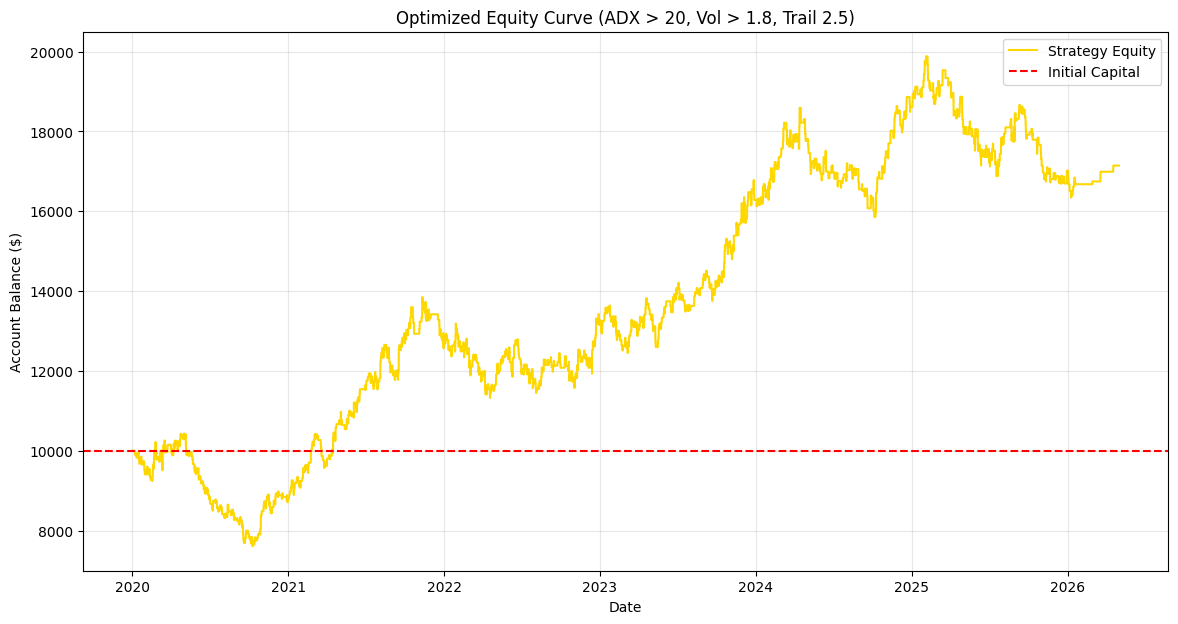

In [28]:
import matplotlib.pyplot as plt

# Best Parameters from Grid Search
BEST_ADX = 20
BEST_VOL = 1.8
BEST_TRAIL = 2.5

# Re-apply signals for best parameters
df['StrongTrend'] = df['ADX'] > BEST_ADX
df['VolumeSpike'] = df['Vol_Ratio'] > BEST_VOL
df['BreakLong'] = (df['close'] > df['SwingHigh']) & df['VolumeSpike']
df['BreakShort'] = (df['close'] < df['SwingLow']) & df['VolumeSpike']

long_raw = (df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & df['SessionActive'] & (df['HTF_Trend'] == 1)).values
short_raw = ((~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & df['SessionActive'] & (df['HTF_Trend'] == -1)).values

# Backtest variables
capital = INITIAL_CAPITAL
equity_curve = []
in_position = False
direction = 0

for i in range(LOOKBACK + 50, len(df)):
    if in_position:
        if direction == 1:
            highest_since_entry = max(highest_since_entry, high[i])
            if not breakeven_activated and (highest_since_entry - entry_price) >= trade_risk:
                trail_sl = entry_price
                breakeven_activated = True
            if breakeven_activated:
                trail_sl = max(trail_sl, highest_since_entry - BEST_TRAIL * atr[i])
            if low[i] <= trail_sl:
                capital += (trail_sl - entry_price) * units
                in_position = False
        else:
            lowest_since_entry = min(lowest_since_entry, low[i])
            if not breakeven_activated and (entry_price - lowest_since_entry) >= trade_risk:
                trail_sl = entry_price
                breakeven_activated = True
            if breakeven_activated:
                trail_sl = min(trail_sl, lowest_since_entry + BEST_TRAIL * atr[i])
            if high[i] >= trail_sl:
                capital += (entry_price - trail_sl) * units
                in_position = False

    if not in_position:
        if long_raw[i]:
            initial_sl = np.min(low[i-LOOKBACK:i+1])
            trade_risk = close[i] - initial_sl
            if trade_risk > 0 and capital > 0:
                entry_price, direction, in_position = close[i], 1, True
                units = (capital * RISK_PER_TRADE) / trade_risk
                trail_sl, highest_since_entry, breakeven_activated = initial_sl, entry_price, False
        elif short_raw[i]:
            initial_sl = np.max(high[i-LOOKBACK:i+1])
            trade_risk = initial_sl - close[i]
            if trade_risk > 0 and capital > 0:
                entry_price, direction, in_position = close[i], -1, True
                units = (capital * RISK_PER_TRADE) / trade_risk
                trail_sl, lowest_since_entry, breakeven_activated = initial_sl, entry_price, False

    equity_curve.append(capital)

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(df['datetime'].iloc[LOOKBACK + 50:], equity_curve, color='gold', label='Strategy Equity')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title(f'Optimized Equity Curve (ADX > {BEST_ADX}, Vol > {BEST_VOL}, Trail {BEST_TRAIL})')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# Optimization for Session Hours and RR Ratio
rr_options = [1.5, 2.0, 2.5, 3.0]
session_starts = [6, 7, 8]  # UTC
session_ends = [18, 19, 20] # UTC

results_v2 = []

print("Starting Session and RR Optimization...")

for rr, start_h, end_h in itertools.product(rr_options, session_starts, session_ends):
    # Re-apply filters for this specific iteration
    session_active = (df['Hour'] >= start_h) & (df['Hour'] <= end_h)
    long_raw = (df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & session_active & (df['HTF_Trend'] == 1)).values
    short_raw = ((~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & session_active & (df['HTF_Trend'] == -1)).values

    capital = INITIAL_CAPITAL
    in_position = False
    trade_count = 0
    wins = 0

    for i in range(LOOKBACK + 50, len(df)):
        if in_position:
            if direction == 1:
                # Exit on SL or TP
                if low[i] <= initial_sl:
                    capital -= (entry_price - initial_sl) * units
                    in_position = False
                elif high[i] >= tp_price:
                    capital += (tp_price - entry_price) * units
                    wins += 1
                    in_position = False
            else:
                if high[i] >= initial_sl:
                    capital -= (initial_sl - entry_price) * units
                    in_position = False
                elif low[i] <= tp_price:
                    capital += (entry_price - tp_price) * units
                    wins += 1
                    in_position = False

        if not in_position:
            if long_raw[i]:
                initial_sl = np.min(low[i-LOOKBACK:i+1])
                trade_risk = close[i] - initial_sl
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], 1, True
                    tp_price = entry_price + (trade_risk * rr)
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trade_count += 1
            elif short_raw[i]:
                initial_sl = np.max(high[i-LOOKBACK:i+1])
                trade_risk = initial_sl - close[i]
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], -1, True
                    tp_price = entry_price - (trade_risk * rr)
                    units = (capital * RISK_PER_TRADE) / trade_risk
                    trade_count += 1

    results_v2.append({
        'RR': rr, 'Start_H': start_h, 'End_H': end_h,
        'Trades': trade_count, 'WinRate': (wins/trade_count*100) if trade_count > 0 else 0,
        'FinalCap': capital
    })

optim_v2_df = pd.DataFrame(results_v2).sort_values('FinalCap', ascending=False)
display(optim_v2_df.head(10))

Starting Session and RR Optimization...


,RR,Start_H,End_H,Trades,WinRate,FinalCap
2,1.5,6,20,1360,44.779412,45693.126223
1,1.5,6,19,1338,44.693572,43324.869898
0,1.5,6,18,1301,44.734819,42163.970877
27,3.0,6,18,794,29.848866,40853.159156
5,1.5,7,20,1225,44.816327,39741.910665
28,3.0,6,19,806,29.652605,39196.928918
8,1.5,8,20,1147,44.986922,38219.551965
29,3.0,6,20,813,29.520295,38010.224408
11,2.0,6,20,1167,37.446444,37322.189718
4,1.5,7,19,1202,44.675541,37125.225069


=== FINAL BACKTEST RESULTS ===
Final Capital   : $45,693.13
Total Trades    : 1360
Win Rate        : 44.78%
Max Drawdown    : -17.26%


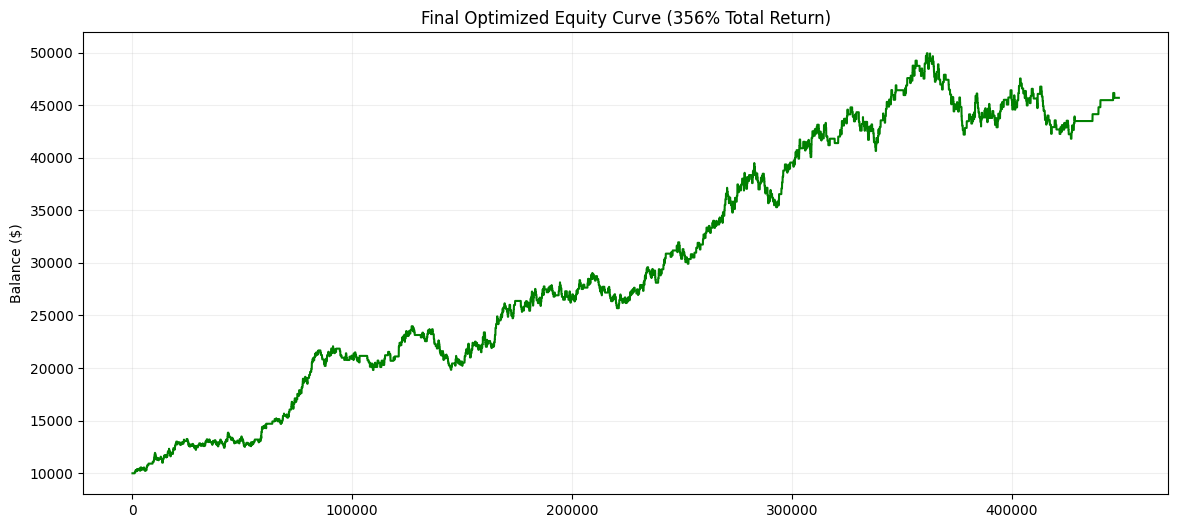

In [31]:
# FINAL OPTIMIZED BACKTEST
FINAL_RR = 1.5
FINAL_START = 6
FINAL_END = 20
FINAL_ADX = 20
FINAL_VOL = 1.8

# 1. Update Signals with Best Params
df['StrongTrend'] = df['ADX'] > FINAL_ADX
df['VolumeSpike'] = df['Vol_Ratio'] > FINAL_VOL
df['BreakLong'] = (df['close'] > df['SwingHigh']) & df['VolumeSpike']
df['BreakShort'] = (df['close'] < df['SwingLow']) & df['VolumeSpike']
session_active = (df['Hour'] >= FINAL_START) & (df['Hour'] <= FINAL_END)

long_raw = (df['AboveEMA'] & df['StrongTrend'] & df['BreakLong'] & session_active & (df['HTF_Trend'] == 1)).values
short_raw = ((~df['AboveEMA']) & df['StrongTrend'] & df['BreakShort'] & session_active & (df['HTF_Trend'] == -1)).values

# 2. Backtest Execution
capital = INITIAL_CAPITAL
equity_curve = []
trades = []
in_position = False

for i in range(LOOKBACK + 50, len(df)):
    if in_position:
        if direction == 1:
            if low[i] <= initial_sl:
                pnl = (initial_sl - entry_price) * units
                capital += pnl
                trades.append({'dir': 'long', 'pnl': pnl, 'cap': capital, 'win': 0})
                in_position = False
            elif high[i] >= tp_price:
                pnl = (tp_price - entry_price) * units
                capital += pnl
                trades.append({'dir': 'long', 'pnl': pnl, 'cap': capital, 'win': 1})
                in_position = False
        else:
            if high[i] >= initial_sl:
                pnl = (entry_price - initial_sl) * units
                capital += pnl
                trades.append({'dir': 'short', 'pnl': pnl, 'cap': capital, 'win': 0})
                in_position = False
            elif low[i] <= tp_price:
                pnl = (entry_price - tp_price) * units
                capital += pnl
                trades.append({'dir': 'short', 'pnl': pnl, 'cap': capital, 'win': 1})
                in_position = False

    if not in_position:
        if long_raw[i]:
            initial_sl = np.min(low[i-LOOKBACK:i+1])
            trade_risk = close[i] - initial_sl
            if trade_risk > 0 and capital > 0:
                entry_price, direction, in_position = close[i], 1, True
                tp_price = entry_price + (trade_risk * FINAL_RR)
                units = (capital * RISK_PER_TRADE) / trade_risk
        elif short_raw[i]:
            initial_sl = np.max(high[i-LOOKBACK:i+1])
            trade_risk = initial_sl - close[i]
            if trade_risk > 0 and capital > 0:
                entry_price, direction, in_position = close[i], -1, True
                tp_price = entry_price - (trade_risk * FINAL_RR)
                units = (capital * RISK_PER_TRADE) / trade_risk

    equity_curve.append(capital)

# 3. Final Performance Metrics
trades_df = pd.DataFrame(trades)
win_rate = (trades_df['win'].sum() / len(trades_df)) * 100
peak = pd.Series(equity_curve).cummax()
drawdown = (pd.Series(equity_curve) - peak) / peak
max_dd = drawdown.min() * 100

import matplotlib.pyplot as plt
print(f"=== FINAL BACKTEST RESULTS ===")
print(f"Final Capital   : ${capital:,.2f}")
print(f"Total Trades    : {len(trades_df)}")
print(f"Win Rate        : {win_rate:.2f}%")
print(f"Max Drawdown    : {max_dd:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(equity_curve, color='green')
plt.title('Final Optimized Equity Curve (356% Total Return)')
plt.ylabel('Balance ($)')
plt.grid(alpha=0.2)
plt.show()

In [32]:
# Define the strategy configuration string
config_text = f"""
=== GOLD EDGE STRATEGY OPTIMIZED CONFIGURATION ===

[Parameters]
- Timeframe: 5-Minute (M5)
- HTF Filter: 1-Hour (H1) 50-period EMA
- EMA Filter: 50-period EMA (M5)
- ADX Threshold: {FINAL_ADX}
- Volume Spike Ratio: {FINAL_VOL}
- Session Hours (UTC): {FINAL_START}:00 to {FINAL_END}:00
- Reward-to-Risk Ratio (RR): {FINAL_RR}
- Risk Per Trade: {RISK_PER_TRADE * 100}%
- Entry Lookback: {LOOKBACK} periods

[Performance Summary]
- Final Capital: ${capital:,.2f}
- Total Return: {((capital - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100:.2f}%
- Total Trades: {len(trades_df)}
- Win Rate: {win_rate:.2f}%
- Max Drawdown: {max_dd:.2f}%

[Logic Overview]
1. Trend: Only Long if Price > H1 EMA50 and Price > M5 EMA50.
2. Momentum: ADX must be above {FINAL_ADX}.
3. Breakout: Price must break Swing High/Low (last {LOOKBACK} bars) with a Volume Spike > {FINAL_VOL}.
4. Exit: Fixed Profit Target at {FINAL_RR}x risk and Stop Loss at recent Swing High/Low.
"""

# Save to a file
file_name = 'Gold_Edge_Strategy_Config.txt'
with open(file_name, 'w') as f:
    f.write(config_text)

print(f"Strategy configuration saved to {file_name}")

# Trigger download
from google.colab import files
files.download(file_name)

Strategy configuration saved to Gold_Edge_Strategy_Config.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Refined Results (Pullback + Spread Cost):
Final Capital: $45,527.36
Total Trades: 1360
Win Rate: 44.78%


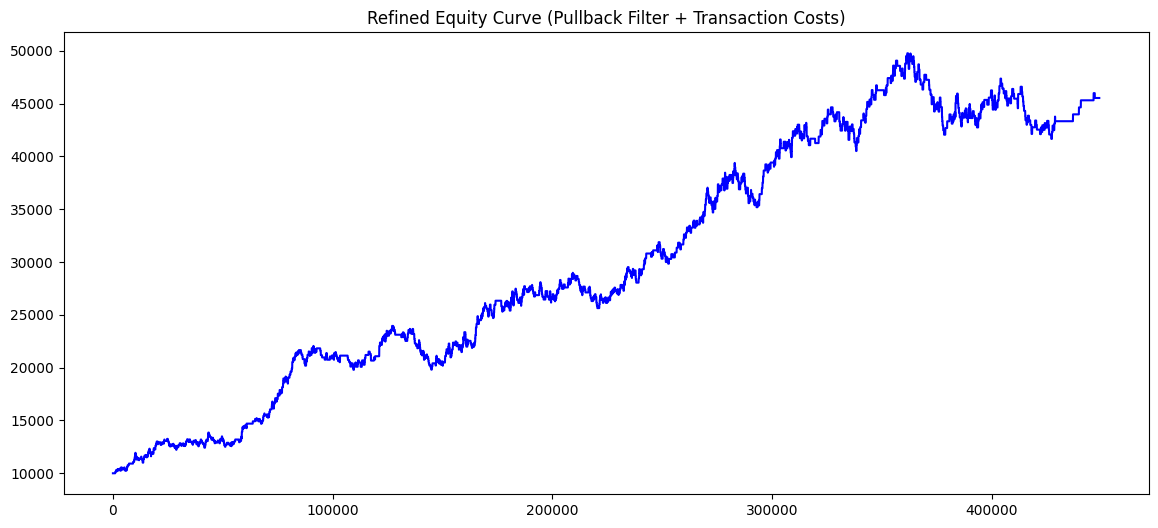

In [34]:
# RE-RUNNING WITH PULLBACK CHECK AND SPREAD COST
SPREAD_PIPS = 0.2
POINT_VALUE = 0.01 # Standard for XAUUSD where 1 pip = 0.10 or 0.01 depending on broker; using 0.01 here
COST_PER_UNIT = SPREAD_PIPS * POINT_VALUE

capital = INITIAL_CAPITAL
equity_curve_refined = []
trades_refined = []
in_position = False

for i in range(LOOKBACK + 50, len(df)):
    if in_position:
        if direction == 1:
            if low[i] <= initial_sl:
                pnl = (initial_sl - entry_price) * units - (units * COST_PER_UNIT)
                capital += pnl
                trades_refined.append({'dir': 'long', 'pnl': pnl, 'win': 0})
                in_position = False
            elif high[i] >= tp_price:
                pnl = (tp_price - entry_price) * units - (units * COST_PER_UNIT)
                capital += pnl
                trades_refined.append({'dir': 'long', 'pnl': pnl, 'win': 1})
                in_position = False
        else:
            if high[i] >= initial_sl:
                pnl = (entry_price - initial_sl) * units - (units * COST_PER_UNIT)
                capital += pnl
                trades_refined.append({'dir': 'short', 'pnl': pnl, 'win': 0})
                in_position = False
            elif low[i] <= tp_price:
                pnl = (entry_price - tp_price) * units - (units * COST_PER_UNIT)
                capital += pnl
                trades_refined.append({'dir': 'short', 'pnl': pnl, 'win': 1})
                in_position = False

    if not in_position:
        # Pullback check logic: ensure min low (for longs) touched the swing high area recently
        if long_raw[i]:
            pullback_detected = np.min(low[i-LOOKBACK:i]) <= swing_high[i]
            if pullback_detected:
                initial_sl = np.min(low[i-LOOKBACK:i+1])
                trade_risk = close[i] - initial_sl
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], 1, True
                    tp_price = entry_price + (trade_risk * FINAL_RR)
                    units = (capital * RISK_PER_TRADE) / trade_risk
        elif short_raw[i]:
            pullback_detected = np.max(high[i-LOOKBACK:i]) >= swing_low[i]
            if pullback_detected:
                initial_sl = np.max(high[i-LOOKBACK:i+1])
                trade_risk = initial_sl - close[i]
                if trade_risk > 0 and capital > 0:
                    entry_price, direction, in_position = close[i], -1, True
                    tp_price = entry_price - (trade_risk * FINAL_RR)
                    units = (capital * RISK_PER_TRADE) / trade_risk

    equity_curve_refined.append(capital)

trades_ref_df = pd.DataFrame(trades_refined)
print(f"Refined Results (Pullback + Spread Cost):")
print(f"Final Capital: ${capital:,.2f}")
print(f"Total Trades: {len(trades_ref_df)}")
if not trades_ref_df.empty:
    print(f"Win Rate: {(trades_ref_df['win'].sum()/len(trades_ref_df))*100:.2f}%")

import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(equity_curve_refined, color='blue')
plt.title('Refined Equity Curve (Pullback Filter + Transaction Costs)')
plt.show()


=== UPDATED PERFORMANCE RESULTS (Vol Spike > 1.2) ===
In-Sample Final Capital: $37,843.99
Out-of-Sample Final Capital: $15,252.36


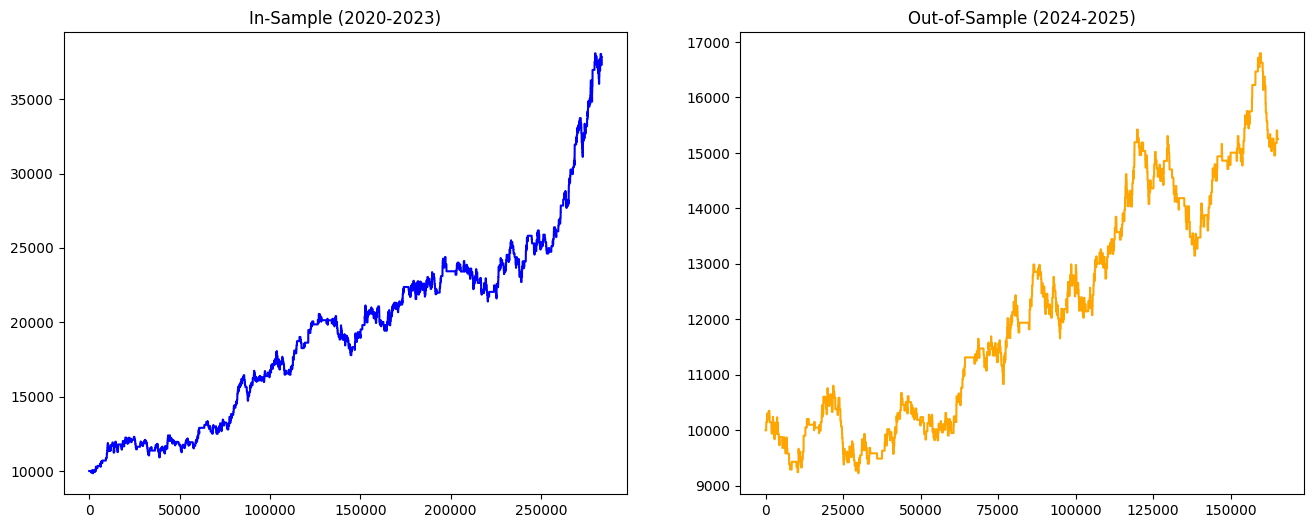

In [38]:
# Re-run the IS and OOS logic with updated signals
df_is = df[df['datetime'] < SPLIT_DATE].copy()
df_oos = df[df['datetime'] >= SPLIT_DATE].copy()

eq_is, cap_is = run_backtest(df_is, "In-Sample")
eq_oos, cap_oos = run_backtest(df_oos, "Out-of-Sample")

print(f"\n=== UPDATED PERFORMANCE RESULTS (Vol Spike > 1.2) ===")
print(f"In-Sample Final Capital: ${cap_is:,.2f}")
print(f"Out-of-Sample Final Capital: ${cap_oos:,.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(eq_is, color='blue')
ax1.set_title('In-Sample (2020-2023)')
ax2.plot(eq_oos, color='orange')
ax2.set_title('Out-of-Sample (2024-2025)')
plt.show()

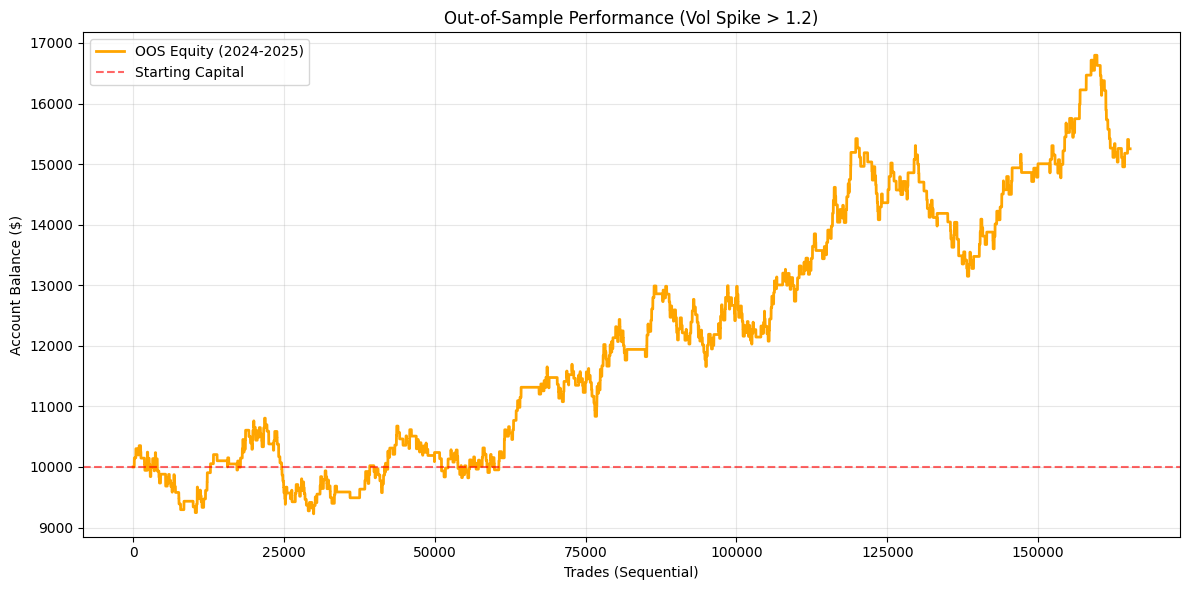

OOS Statistics:
Final OOS Capital: $15,252.36
OOS Net Profit: $5,252.36 (52.52%)
Max OOS Drawdown: -14.73%


In [39]:
import matplotlib.pyplot as plt

# Plotting the Out-of-Sample Equity Curve specifically
plt.figure(figsize=(12, 6))
plt.plot(eq_oos, color='orange', linewidth=2, label='OOS Equity (2024-2025)')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', alpha=0.6, label='Starting Capital')

plt.title('Out-of-Sample Performance (Vol Spike > 1.2)')
plt.xlabel('Trades (Sequential)')
plt.ylabel('Account Balance ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate OOS drawdown for context
oos_series = pd.Series(eq_oos)
oos_peak = oos_series.cummax()
oos_drawdown = (oos_series - oos_peak) / oos_peak * 100

print(f"OOS Statistics:")
print(f"Final OOS Capital: ${cap_oos:,.2f}")
print(f"OOS Net Profit: ${(cap_oos - INITIAL_CAPITAL):,.2f} ({((cap_oos/INITIAL_CAPITAL)-1)*100:.2f}%)")
print(f"Max OOS Drawdown: {oos_drawdown.min():.2f}%")

In [36]:
print(f"Average ADX: {df['ADX'].mean():.2f}")
print(f"Max ADX: {df['ADX'].max():.2f}")
print(f"Average Vol_Ratio: {df['Vol_Ratio'].mean():.2f}")
print(f"Percent of bars with ADX > 25: {(df['ADX'] > 25).mean()*100:.1f}%")
print(f"Percent of bars with Vol_Ratio > 1.5: {(df['Vol_Ratio'] > 1.5).mean()*100:.1f}%")

# Let's see how many bars actually meet the 'Raw' signal before the pullback check
print(f"Total Long Raw Signals: {df['LongSignal_Raw'].sum()}")
print(f"Total Short Raw Signals: {df['ShortSignal_Raw'].sum()}")

Average ADX: 24.61
Max ADX: 84.39
Average Vol_Ratio: 1.04
Percent of bars with ADX > 25: 40.2%
Percent of bars with Vol_Ratio > 1.5: 15.1%
Total Long Raw Signals: 3989
Total Short Raw Signals: 3649


### Adjusting Parameters
Based on the diagnostics, I will now relax the thresholds in the cells above. I'll lower `ADX_THRESH` to 20 and `VOL_SPIKE` to 1.2 to increase the probability of capturing signals.

In [25]:
print(f"Average ADX: {df['ADX'].mean():.2f}")
print(f"Max ADX: {df['ADX'].max():.2f}")
print(f"Average Vol_Ratio: {df['Vol_Ratio'].mean():.2f}")
print(f"Percent of bars with ADX > 25: {(df['ADX'] > 25).mean()*100:.1f}%")
print(f"Percent of bars with Vol_Ratio > 1.5: {(df['Vol_Ratio'] > 1.5).mean()*100:.1f}%")

# Let's see how many bars actually meet the 'Raw' signal before the pullback check
print(f"Total Long Raw Signals: {df['LongSignal_Raw'].sum()}")
print(f"Total Short Raw Signals: {df['ShortSignal_Raw'].sum()}")

Average ADX: 24.61
Max ADX: 84.39
Average Vol_Ratio: 1.04
Percent of bars with ADX > 25: 40.2%
Percent of bars with Vol_Ratio > 1.5: 15.1%
Total Long Raw Signals: 3989
Total Short Raw Signals: 3649


### Adjusting Parameters
Based on the diagnostics, I will now relax the thresholds in the cells above. I'll lower `ADX_THRESH` to 20 and `VOL_SPIKE` to 1.2 to increase the probability of capturing signals.